In [103]:
import osmnx as ox
place_name = 'Bothell, Washington, USA' # Change this to switch cities
G = ox.graph_from_place(place_name, network_type='drive')
# Ensure the graph is strongly connected (guarantees a return path exists)
#G = ox.utils_graph.get_largest_component(G, strongly=True)

start_node = list(G.nodes)[350]  # Arbitrary starting node
end_node = list(G.neighbors(start_node))[0]

In [104]:
type(G)

networkx.classes.multidigraph.MultiDiGraph

In [105]:
len(G.nodes)

1909

In [106]:
len(G.edges)

4454

In [107]:
list(G.edges(data=True))[0]

(30139137,
 30552368,
 {'osmid': 41656207,
  'highway': 'primary_link',
  'oneway': True,
  'reversed': False,
  'length': np.float64(68.65350669736786),
  'geometry': <LINESTRING (-122.199 47.759, -122.199 47.759, -122.199 47.759, -122.199 47....>})

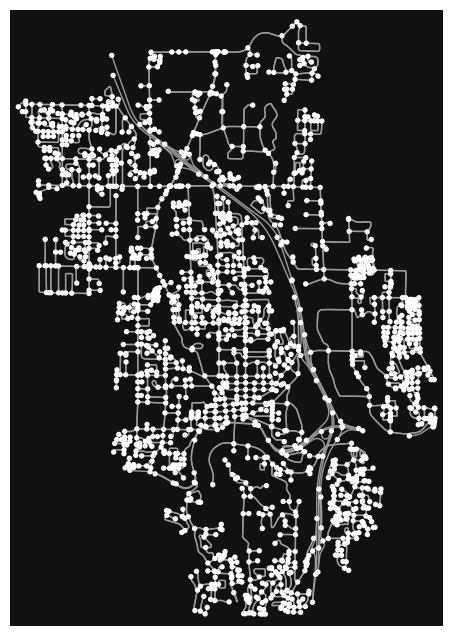

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [108]:
ox.plot_graph(G)


In [109]:
list(G.nodes(data=True))[0]

(30139137,
 {'y': 47.7589995,
  'x': -122.1990157,
  'highway': 'motorway_junction',
  'street_count': 3})

In [110]:
ox.settings.elevation_url_template = (
    "https://api.opentopodata.org/v1/aster30m?locations={locations}"
)
G = ox.elevation.add_node_elevations_google(G, batch_size=100, pause=1)
G = ox.elevation.add_edge_grades(G)
print(list(G.nodes(data=True))[0])
print(list(G.edges(data=True))[0])

(30139137, {'y': 47.7589995, 'x': -122.1990157, 'highway': 'motorway_junction', 'street_count': 3, 'elevation': 12.0})
(30139137, 30552368, {'osmid': 41656207, 'highway': 'primary_link', 'oneway': True, 'reversed': False, 'length': np.float64(68.65350669736786), 'geometry': <LINESTRING (-122.199 47.759, -122.199 47.759, -122.199 47.759, -122.199 47....>, 'grade': np.float64(0.014565898351093834), 'grade_abs': np.float64(0.014565898351093834)})


In [111]:
gdf_nodes, gdf_edges = ox.convert.graph_to_gdfs(G)
print(gdf_nodes.shape)
print(gdf_edges.shape)
gdf_edges.head()

(1909, 7)
(4454, 16)


osmid  \
u        v           key                                                      
30139137 30552368    0                                             41656207   
         2263351021  0                                            428096454   
30139395 2468337237  0                                             55151552   
         13527803327 0                                           1474595693   
30139406 306726782   0    [314941848, 291708009, 314941847, 55151544, 10...   

                                highway  oneway reversed      length  \
u        v           key                                               
30139137 30552368    0     primary_link    True    False   68.653507   
         2263351021  0          primary    True    False   49.349393   
30139395 2468337237  0    motorway_link    True    False  297.839075   
         13527803327 0         motorway    True    False  251.230667   
30139406 306726782   0    motorway_link    True    False  545.067034   

                                                                   geometry  \
u        v           key                                                      
30139137 30552368    0    LINESTRING (-122.19902 47.759, -122.19931 47.7...   
         2263351021  0    LINESTRING (-122.19902 47.759, -122.19909 47.7...   
30139395 2468337237  0    LINESTRING (-122.17886 47.75859, -122.17981 47...   
         13527803327 0    LINESTRING (-122.17886 47.75859, -122.18046 47...   
30139406 306726782   0    LINESTRING (-122.18793 47.76654, -122.18796 47...   

                             grade  grade_abs   lanes maxspeed  \
u        v           key                                         
30139137 30552368    0    0.014566   0.014566     NaN      NaN   
         2263351021  0   -0.020264   0.020264       3   35 mph   
30139395 2468337237  0    0.003358   0.003358       1      NaN   
         13527803327 0    0.007961   0.007961       2   60 mph   
30139406 306726782   0    0.000000   0.000000  [1, 2]      NaN   

                                       name     ref bridge width access  \
u        v           key                                                  
30139137 30552368    0                  NaN     NaN    NaN   NaN    NaN   
         2263351021  0    Woodinville Drive  WA 522    NaN   NaN    NaN   
30139395 2468337237  0                  NaN     NaN    NaN   NaN    NaN   
         13527803327 0                  NaN  WA 522    NaN   NaN    NaN   
30139406 306726782   0                  NaN     NaN    yes   NaN    NaN   

                         junction  
u        v           key           
30139137 30552368    0        NaN  
         2263351021  0        NaN  
30139395 2468337237  0        NaN  
         13527803327 0        NaN  
30139406 306726782   0        NaN

In [112]:
gdf_edges.index[0]

(np.int64(30139137), np.int64(30552368), np.int64(0))

In [113]:
gdf_edges['maxspeed'].isnull().sum()

np.int64(3841)

In [114]:
gdf_edges['highway'] = gdf_edges['highway'].apply(lambda x: x[0] if isinstance(x, list) else x)
print(gdf_edges['highway'].unique())
print(gdf_edges['highway'].isnull().sum())

<StringArray>
[  'primary_link',        'primary',  'motorway_link',       'motorway',
       'tertiary',      'secondary',    'residential',  'living_street',
          'trunk',   'unclassified', 'secondary_link',     'trunk_link',
  'tertiary_link']
Length: 13, dtype: str
0


<Axes: >

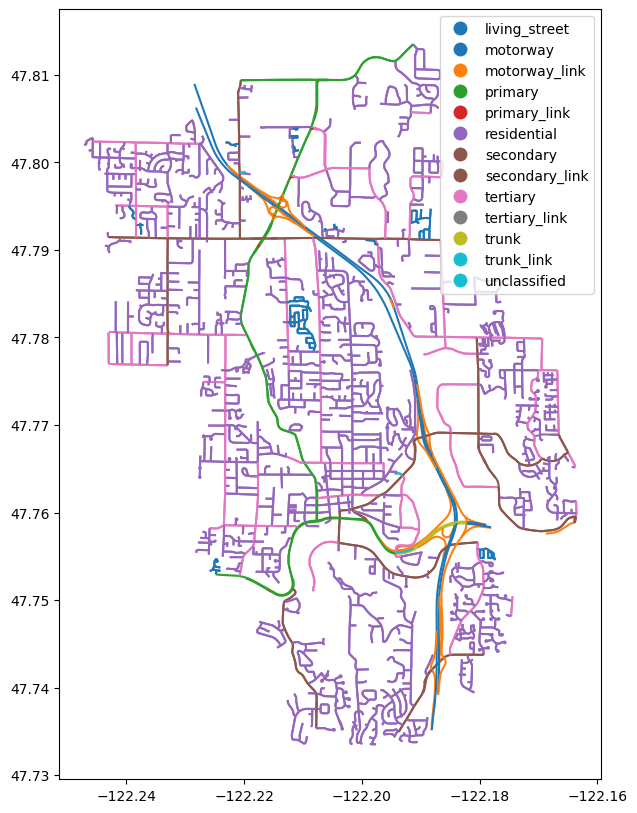

In [115]:
gdf_edges.plot(column='highway', figsize=(10, 10), legend=True)

In [116]:
default_speed = {
    'motorway': '60', 'motorway_link': '45', 'trunk': '55', 'trunk_link': '40',
    'primary': '45', 'primary_link': '40', 'secondary': '35', 'secondary_link': '30',
    'tertiary': '30', 'tertiary_link': '25', 'residential': '25', 'unclassified': '25', 'living_street': '10'
}

# Clean and convert maxspeed
gdf_edges['maxspeed'] = gdf_edges['maxspeed'].apply(lambda x: x[0] if isinstance(x, list) else x)
gdf_edges['maxspeed'] = gdf_edges['maxspeed'].fillna(gdf_edges['highway'].map(default_speed))
gdf_edges['maxspeed'] = gdf_edges['maxspeed'].fillna('25').str.replace(' mph', '', regex=False)
gdf_edges['maxspeed'] = gdf_edges['maxspeed'].astype(float).astype(int)

In [117]:
gdf_edges['maxspeed'].isnull().sum()
gdf_edges['maxspeed'].dtype

dtype('int64')

In [118]:
import shapely as shp
import math
help(math.atan2)

Help on built-in function atan2 in module math:

atan2(y, x, /)
    Return the arc tangent (measured in radians) of y/x.

    Unlike atan(y/x), the signs of both x and y are considered.



In [119]:
from shapely import LineString


def compute_curvature(LineString):

    x, y = LineString.coords.xy
    currX = None
    currY = None
    bearing = 0
    prevbearing = None
    currbearing = None
    for n in range(len(x)):
        if n == 0:
            currX = x[n]
            currY = y[n]
        elif prevbearing is None:
            nextX = x[n]
            nextY = y[n]
            prevbearing = math.atan2(nextY - currY, nextX - currX)
            currX = nextX
            currY = nextY
        else:
            nextX = x[n]
            nextY = y[n]
            currbearing = math.atan2(nextY - currY, nextX - currX)
            diffBearing = abs(currbearing - prevbearing)
            diffBearing = min(diffBearing, math.pi)
            bearing = diffBearing - (math.pi*2) + bearing if diffBearing > math.pi else diffBearing + bearing
            prevbearing = currbearing
            currX = nextX
            currY = nextY

    return bearing
test_geom = gdf_edges['geometry'].iloc[0]
print(test_geom)
compute_curvature(test_geom)
for x in gdf_edges['geometry']:
    print(compute_curvature(x))
        

LINESTRING (-122.1990157 47.7589995, -122.1993072 47.7592619, -122.1993438 47.7592893, -122.199429 47.7593418, -122.1994846 47.7593695, -122.1995701 47.7594042, -122.1996538 47.7594296)
0.43827742986671714
0.15530726381493487
0.3668474620498401
0.0877215917460803
1.0327627587207597
0.7890174579638993
2.3672762504815217
4.249314134365038
15.998100757313647
0.03417752753803908
0.09324035173956702
2.037664645591003
0.03417752753803871
0.1637865720813212
0.0021277622856812877
0.00031028459469295555
0.0028499282824752115
1.8195699515625279
0.3849263725291603
1.0100983864431692
0.00020961173230377855
0.4699867820364081
0.3849263725291605
1.2901638686125305
0.9197373912884768
0.46998678203640853
0
7.2962441548345485
0.06402978187519381
0.9197373912884778
5.374893252209114
0.45378399831148397
0.3428978619683658
0.20041553880578244
0.6936473400218801
0.02532465694196695
2.1675310139524773
0.9297270514207427
0.4641773523275804
1.183067044041419
0.3451434451069917
0.21861573577604543
3.1852640385

In [120]:
gdf_edges['curvature'] = gdf_edges['geometry'].apply(compute_curvature)
gdf_edges['curvature'].idxmax()

(np.int64(5041319726), np.int64(50707517), np.int64(0))

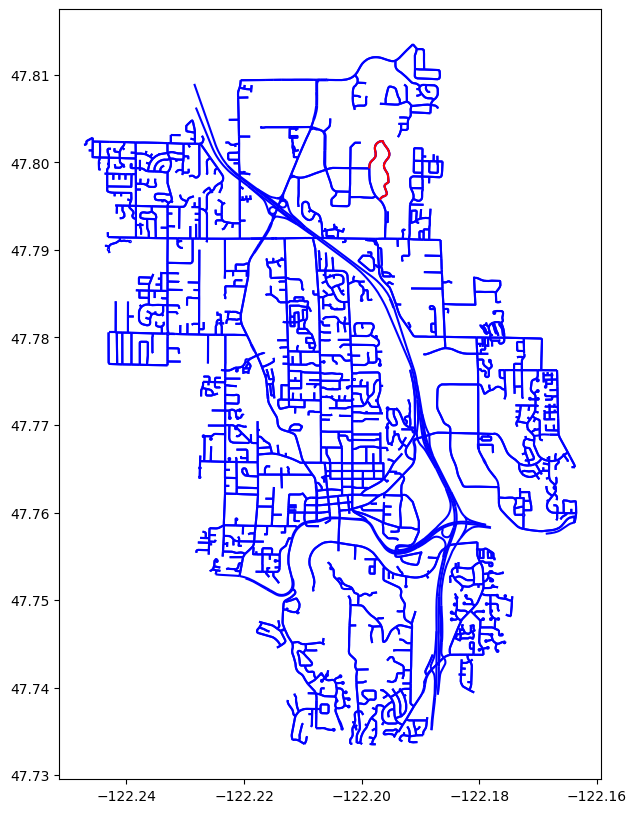

In [121]:
import matplotlib.pyplot as plt
max_curve =gdf_edges[gdf_edges['curvature'] == gdf_edges['curvature'].max()]
fig, ax = plt.subplots(figsize=(10, 10))
gdf_edges.plot(ax =ax, color='blue', legend=True)
max_curve.plot(ax=ax, color='red', label='Max Curvature')
plt.show()




<Axes: >

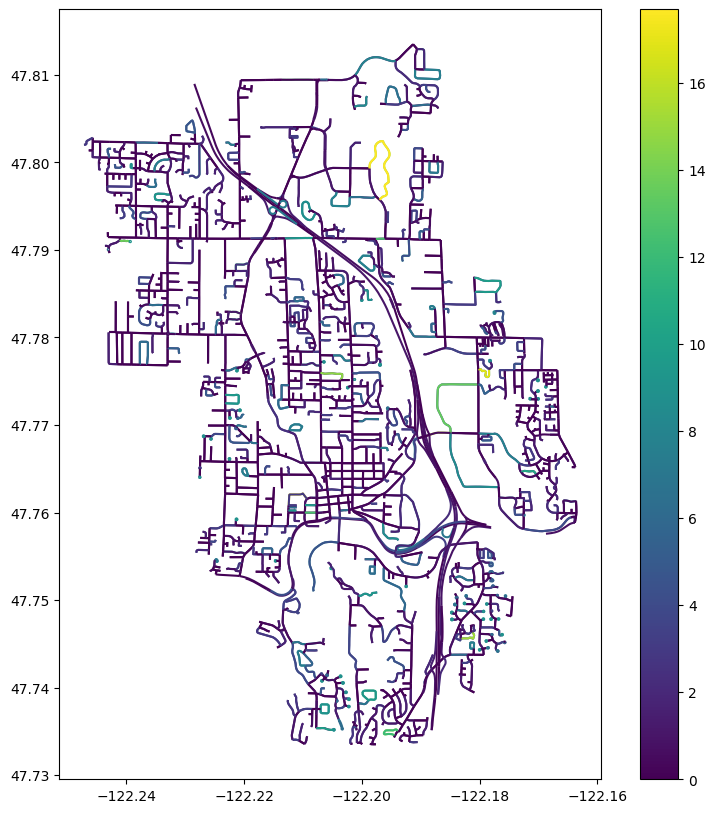

In [122]:
gdf_edges.plot(column='curvature', figsize=(10, 10), legend=True)

In [123]:
gdf_nodes.head()

,y,x,highway,street_count,elevation,ref,geometry
osmid,,,,,,,
30139137,47.759000,-122.199016,motorway_junction,3,12.0,NaN,POINT (-122.19902 47.759)
30139395,47.758586,-122.178860,motorway_junction,3,7.0,NaN,POINT (-122.17886 47.75859)
30139406,47.766544,-122.187931,motorway_junction,3,10.0,24,POINT (-122.18793 47.76654)
30139415,47.769089,-122.184923,traffic_signals,4,10.0,NaN,POINT (-122.18492 47.76909)
30139416,47.769022,-122.180182,traffic_signals,4,9.0,NaN,POINT (-122.18018 47.76902)


In [124]:
gdf_edges.head()

osmid  \
u        v           key                                                      
30139137 30552368    0                                             41656207   
         2263351021  0                                            428096454   
30139395 2468337237  0                                             55151552   
         13527803327 0                                           1474595693   
30139406 306726782   0    [314941848, 291708009, 314941847, 55151544, 10...   

                                highway  oneway reversed      length  \
u        v           key                                               
30139137 30552368    0     primary_link    True    False   68.653507   
         2263351021  0          primary    True    False   49.349393   
30139395 2468337237  0    motorway_link    True    False  297.839075   
         13527803327 0         motorway    True    False  251.230667   
30139406 306726782   0    motorway_link    True    False  545.067034   

                                                                   geometry  \
u        v           key                                                      
30139137 30552368    0    LINESTRING (-122.19902 47.759, -122.19931 47.7...   
         2263351021  0    LINESTRING (-122.19902 47.759, -122.19909 47.7...   
30139395 2468337237  0    LINESTRING (-122.17886 47.75859, -122.17981 47...   
         13527803327 0    LINESTRING (-122.17886 47.75859, -122.18046 47...   
30139406 306726782   0    LINESTRING (-122.18793 47.76654, -122.18796 47...   

                             grade  grade_abs   lanes  maxspeed  \
u        v           key                                          
30139137 30552368    0    0.014566   0.014566     NaN        40   
         2263351021  0   -0.020264   0.020264       3        35   
30139395 2468337237  0    0.003358   0.003358       1        45   
         13527803327 0    0.007961   0.007961       2        60   
30139406 306726782   0    0.000000   0.000000  [1, 2]        45   

                                       name     ref bridge width access  \
u        v           key                                                  
30139137 30552368    0                  NaN     NaN    NaN   NaN    NaN   
         2263351021  0    Woodinville Drive  WA 522    NaN   NaN    NaN   
30139395 2468337237  0                  NaN     NaN    NaN   NaN    NaN   
         13527803327 0                  NaN  WA 522    NaN   NaN    NaN   
30139406 306726782   0                  NaN     NaN    yes   NaN    NaN   

                         junction  curvature  
u        v           key                      
30139137 30552368    0        NaN   0.438277  
         2263351021  0        NaN   0.155307  
30139395 2468337237  0        NaN   0.366847  
         13527803327 0        NaN   0.087722  
30139406 306726782   0        NaN   1.032763

In [125]:
import pandas as pd
df_edges_matrix = gdf_edges[['length', 'maxspeed', 'grade','grade_abs', 'curvature','highway']]
df_highway_dummies = pd.get_dummies(df_edges_matrix['highway'], prefix='highway', drop_first =True)
df_edges_matrix.drop('highway', axis=1, inplace=True)
df_edges_matrix = pd.concat([df_edges_matrix, df_highway_dummies], axis=1)
print(df_edges_matrix.shape)
print(df_edges_matrix.isnull().sum())


(4454, 17)
length                    0
maxspeed                  0
grade                     0
grade_abs                 0
curvature                 0
highway_motorway          0
highway_motorway_link     0
highway_primary           0
highway_primary_link      0
highway_residential       0
highway_secondary         0
highway_secondary_link    0
highway_tertiary          0
highway_tertiary_link     0
highway_trunk             0
highway_trunk_link        0
highway_unclassified      0
dtype: int64


In [126]:
for u, v, d in G.edges(data=True):
      print(u, v, d)
      break

30139137 30552368 {'osmid': 41656207, 'highway': 'primary_link', 'oneway': True, 'reversed': False, 'length': np.float64(68.65350669736786), 'geometry': <LINESTRING (-122.199 47.759, -122.199 47.759, -122.199 47.759, -122.199 47....>, 'grade': np.float64(0.014565898351093834), 'grade_abs': np.float64(0.014565898351093834)}


In [127]:
for u, v, d in G.edges(data=True):
      print(list(d.keys()))
      break

['osmid', 'highway', 'oneway', 'reversed', 'length', 'geometry', 'grade', 'grade_abs']


In [128]:
G = ox.graph_from_gdfs(gdf_nodes, gdf_edges)
for u, v, d in G.edges(data=True):
      print(list(d.keys()))
      break

['osmid', 'highway', 'oneway', 'reversed', 'length', 'geometry', 'grade', 'grade_abs', 'maxspeed', 'curvature']


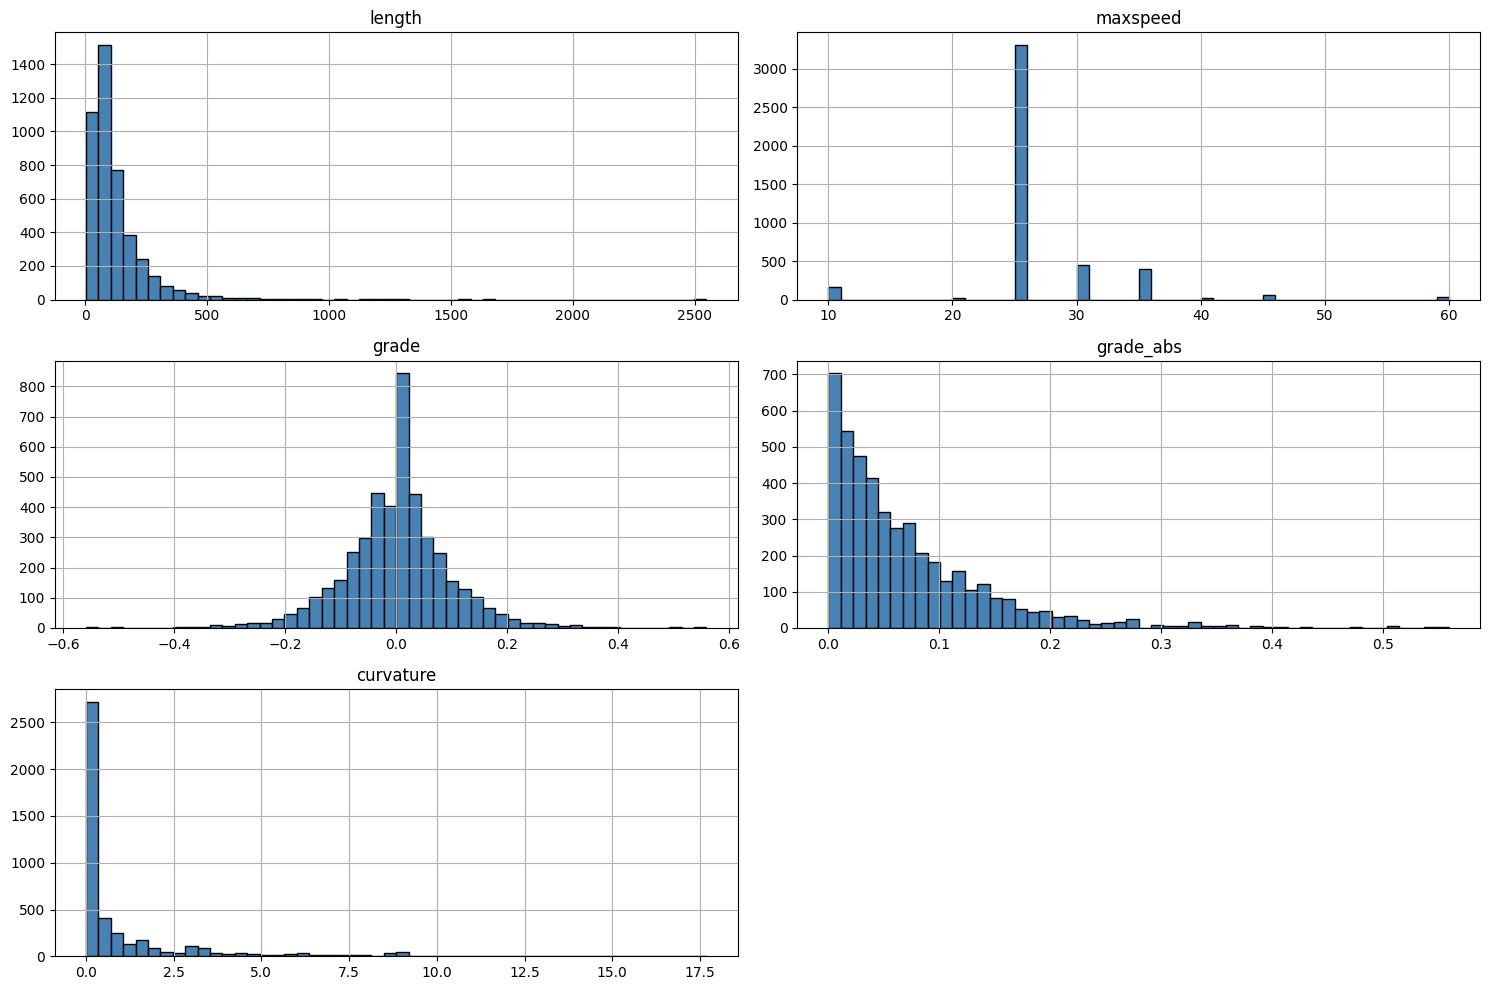

In [129]:
df_edges_matrix.hist(
    figsize=(15, 10), 
    bins=50, 
    color='steelblue', 
    edgecolor='black'
)

# This prevents the subplot titles from overlapping
plt.tight_layout() 

plt.show()

<Axes: >

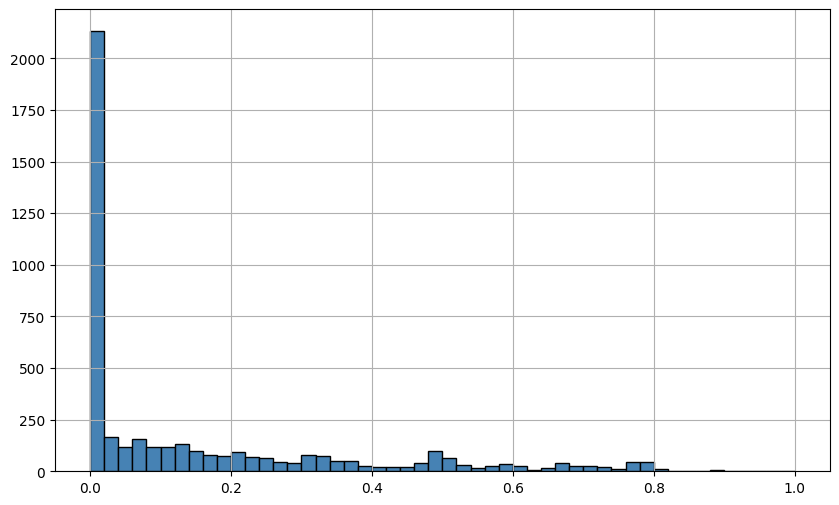

In [130]:
import numpy as np
normalized_gdf_edges = gdf_edges.copy()
normalized_gdf_edges['curvature'] = np.log1p(normalized_gdf_edges['curvature'])
n_min = normalized_gdf_edges['curvature'].min()
n_max = normalized_gdf_edges['curvature'].max()
normalized_gdf_edges['curvature'] = (normalized_gdf_edges['curvature'] - n_min) / (n_max - n_min)
normalized_gdf_edges['curvature'].hist(
    figsize=(10, 6), 
    bins=50, 
    color='steelblue', 
    edgecolor='black'
)

<Axes: >

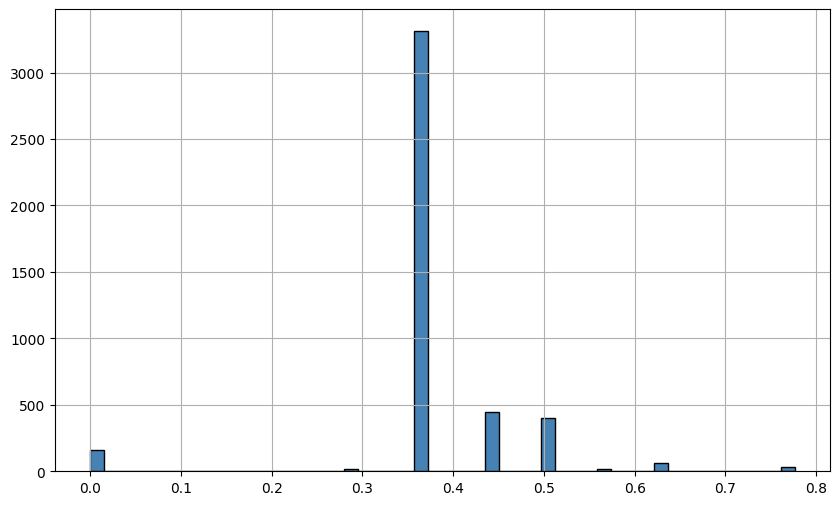

In [131]:
# 10 is a minimum speed limit and 85 is a maximum speed limit
#0.625 gives an exponential distribution with 35mp being the center
normalized_gdf_edges['maxspeed'] = ((normalized_gdf_edges['maxspeed'] - 10) / (85 - 10) )** 0.625 
normalized_gdf_edges['maxspeed'].hist(
    figsize=(10, 6), 
    bins=50, 
    color='steelblue', 
    edgecolor='black'
)

<Axes: >

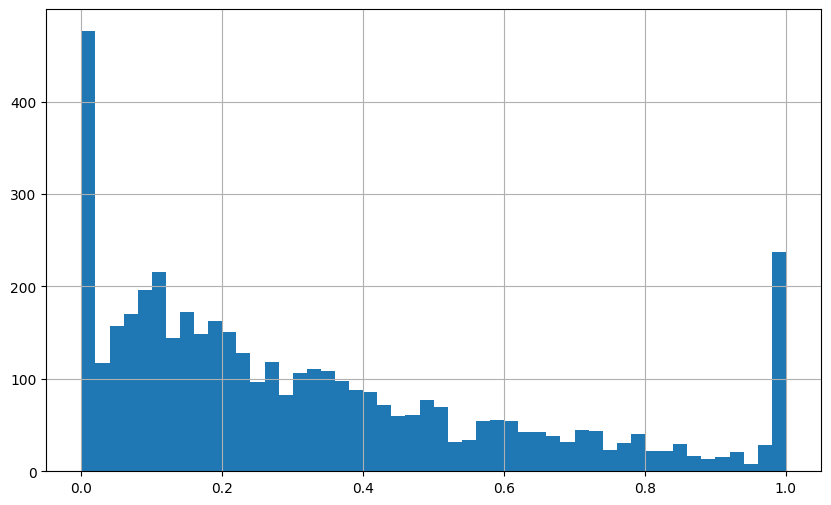

In [132]:
lower_bounds = normalized_gdf_edges['grade_abs'].quantile(0.05)
higher_bounds = normalized_gdf_edges['grade_abs'].quantile(0.95)

normalized_gdf_edges['grade_abs'] = normalized_gdf_edges['grade_abs'].clip(lower=lower_bounds, upper=higher_bounds)
min_grade = normalized_gdf_edges['grade_abs'].min()
max_grade = normalized_gdf_edges['grade_abs'].max()
normalized_gdf_edges['grade_abs'] = (normalized_gdf_edges['grade_abs'] - min_grade) / (max_grade - min_grade)
normalized_gdf_edges['grade_abs'].hist(
    figsize=(10, 6),
    bins=50
)

<Axes: >

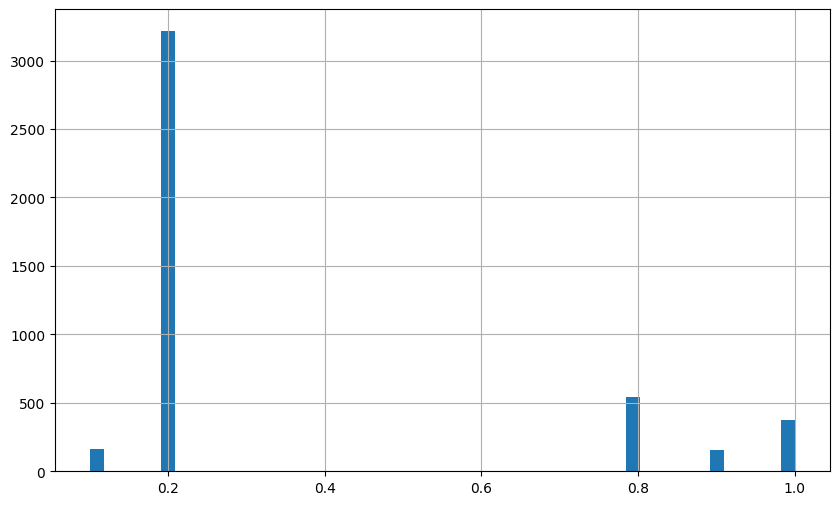

In [133]:
highway_penalties = {
    'residential': 0.2,
    'secondary': 1.0,
    'tertiary': 0.8,
    'primary_link': 0.9,
    'primary': 0.9,
    'unclassified': 0.5,
    'living_street': 0.1
}
normalized_gdf_edges['highway_penalty'] = normalized_gdf_edges['highway'].map(highway_penalties).fillna(1.0)
normalized_gdf_edges['highway_penalty'].hist(
    figsize=(10, 6),
    bins=50
)

In [134]:
G = ox.graph_from_gdfs(gdf_nodes, normalized_gdf_edges)
for u, v, d in G.edges(data=True):
      print(list(d.keys()))
      break
normalized_gdf_edges.head()

['osmid', 'highway', 'oneway', 'reversed', 'length', 'geometry', 'grade', 'grade_abs', 'maxspeed', 'curvature', 'highway_penalty']


osmid  \
u        v           key                                                      
30139137 30552368    0                                             41656207   
         2263351021  0                                            428096454   
30139395 2468337237  0                                             55151552   
         13527803327 0                                           1474595693   
30139406 306726782   0    [314941848, 291708009, 314941847, 55151544, 10...   

                                highway  oneway reversed      length  \
u        v           key                                               
30139137 30552368    0     primary_link    True    False   68.653507   
         2263351021  0          primary    True    False   49.349393   
30139395 2468337237  0    motorway_link    True    False  297.839075   
         13527803327 0         motorway    True    False  251.230667   
30139406 306726782   0    motorway_link    True    False  545.067034   

                                                                   geometry  \
u        v           key                                                      
30139137 30552368    0    LINESTRING (-122.19902 47.759, -122.19931 47.7...   
         2263351021  0    LINESTRING (-122.19902 47.759, -122.19909 47.7...   
30139395 2468337237  0    LINESTRING (-122.17886 47.75859, -122.17981 47...   
         13527803327 0    LINESTRING (-122.17886 47.75859, -122.18046 47...   
30139406 306726782   0    LINESTRING (-122.18793 47.76654, -122.18796 47...   

                             grade  grade_abs   lanes  maxspeed  \
u        v           key                                          
30139137 30552368    0    0.014566   0.073037     NaN  0.564011   
         2263351021  0   -0.020264   0.101608       3  0.503268   
30139395 2468337237  0    0.003358   0.016836       1  0.621054   
         13527803327 0    0.007961   0.039918       2  0.776145   
30139406 306726782   0    0.000000   0.000000  [1, 2]  0.621054   

                                       name     ref bridge width access  \
u        v           key                                                  
30139137 30552368    0                  NaN     NaN    NaN   NaN    NaN   
         2263351021  0    Woodinville Drive  WA 522    NaN   NaN    NaN   
30139395 2468337237  0                  NaN     NaN    NaN   NaN    NaN   
         13527803327 0                  NaN  WA 522    NaN   NaN    NaN   
30139406 306726782   0                  NaN     NaN    yes   NaN    NaN   

                         junction  curvature  highway_penalty  
u        v           key                                       
30139137 30552368    0        NaN   0.124140              0.9  
         2263351021  0        NaN   0.049310              0.9  
30139395 2468337237  0        NaN   0.106741              1.0  
         13527803327 0        NaN   0.028721              1.0  
30139406 306726782   0        NaN   0.242304              1.0

In [135]:
def fun_score(u,v,d):
    score = 0
    d = d[0]
    score += d['maxspeed'] * 0.3
    score += d['grade_abs'] * 0.1
    score += d['curvature'] * 0.4
    score += d['highway_penalty'] * 0.2
    return (1 - score) * d['length']
    

In [136]:
import networkx as nx
u, v, key = gdf_edges.index[0]
nx.dijkstra_path(G, u, v, weight=fun_score)

[np.int64(30139137), np.int64(30552368)]

In [137]:
G.nodes[u]

{'y': 47.7589995,
 'x': -122.1990157,
 'highway': 'motorway_junction',
 'street_count': 3,
 'elevation': 12.0}

In [138]:
for u, v, d in G.edges(data=True):
      print(list(d.keys()))
      break
print(normalized_gdf_edges['curvature'].isnull().sum())
print(gdf_edges['curvature'].isnull().sum())
if normalized_gdf_edges['curvature'].isnull:
    print(normalized_gdf_edges['geometry'])
print(gdf_edges['curvature'].min())

['osmid', 'highway', 'oneway', 'reversed', 'length', 'geometry', 'grade', 'grade_abs', 'maxspeed', 'curvature', 'highway_penalty']
0
0
u            v            key
30139137     30552368     0      LINESTRING (-122.19902 47.759, -122.19931 47.7...
             2263351021   0      LINESTRING (-122.19902 47.759, -122.19909 47.7...
30139395     2468337237   0      LINESTRING (-122.17886 47.75859, -122.17981 47...
             13527803327  0      LINESTRING (-122.17886 47.75859, -122.18046 47...
30139406     306726782    0      LINESTRING (-122.18793 47.76654, -122.18796 47...
                                                       ...                        
13793420015  50692023     0      LINESTRING (-122.23439 47.8009, -122.23428 47....
13793420016  13793420015  0      LINESTRING (-122.23446 47.80103, -122.23439 47...
13805250758  2597201385   0      LINESTRING (-122.19887 47.79127, -122.19917 47...
             50710760     0      LINESTRING (-122.19887 47.79127, -122.19782 47...
     

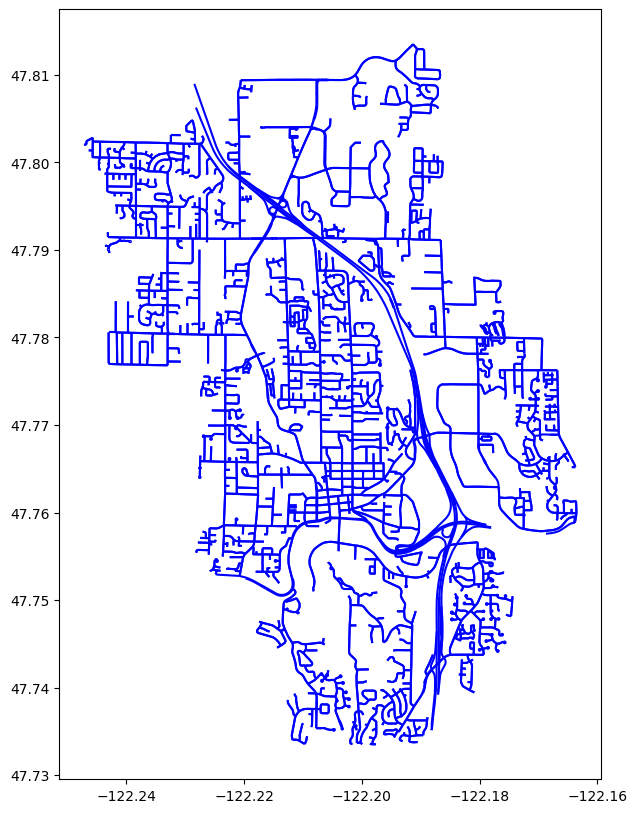

In [139]:
null_curve = normalized_gdf_edges[normalized_gdf_edges['curvature'].isnull()]
fig, ax = plt.subplots(figsize=(10, 10))
normalized_gdf_edges.plot(ax=ax, color='blue', legend=True)

if not null_curve.empty:
	null_curve.plot(ax=ax, color='red', label='Null Curvature')

plt.show()

In [140]:
distance, path = nx.single_source_dijkstra(G, u, cutoff= 20000, weight="length")
filter_distance_dict = {k: v for k, v in distance.items() if v >= 5000 and v < 20000}
print(filter_distance_dict)
len(filter_distance_dict)

{1719505210: 5004.071697035083, 288633697: 5007.07205249966, 50700761: 5020.302050539258, 3551964180: 5023.0429492226285, 50812401: 5030.846841083768, 50700763: 5033.493251835235, 31193651: 5036.40159053192, 1719505212: 5037.121220139256, 53250409: 5040.79367602108, 50720284: 5056.532006051794, 1719505228: 5057.557152362265, 2597557616: 5058.652897800205, 4604660226: 5066.40758303404, 50747511: 5066.709688179108, 4604660227: 5070.839667458911, 135718888: 5071.068928247086, 50687046: 5076.579838941456, 53106767: 5083.668674015692, 3551964181: 5084.590631584961, 30139431: 5085.334375185059, 6846555009: 5086.174304463519, 4604660217: 5091.584417027255, 50797715: 5093.612245367659, 3551964179: 5095.323143765237, 3551964182: 5096.13500414952, 30757994: 5097.686979818111, 296309534: 5098.822793658564, 30757967: 5106.320254820651, 4677213178: 5110.251917280262, 7229921500: 5111.630621266151, 50790788: 5112.212788306909, 50783122: 5112.3451334884085, 4604660219: 5115.698574027395, 286303838: 5

423

In [141]:
nx.single_source_dijkstra(G, u, cutoff= 20000, weight="length")
distance_fun, path_fun = nx.single_source_dijkstra(G, u, weight=fun_score) 
dest = min(filter_distance_dict, key=lambda n: distance_fun[n]) 

In [142]:
print(path_fun[dest])

[30139137, 2263351021, 2263351020, 1036657713, 30320269, 30321103, 30320197, 280302895, 53119454, 53119461, 3733472443, 2468350754, 30234950]


In [143]:
return_path = nx.dijkstra_path(G,dest, u, weight=fun_score)
print(return_path)

[30234950, 30234952, 30139406, 3900899026, 31190954, 130166673, 30234997, 1923361267, 1036657756, 30139137]


In [144]:
round_trip = path_fun[dest] + return_path[1:]
print(round_trip)

[30139137, 2263351021, 2263351020, 1036657713, 30320269, 30321103, 30320197, 280302895, 53119454, 53119461, 3733472443, 2468350754, 30234950, 30234952, 30139406, 3900899026, 31190954, 130166673, 30234997, 1923361267, 1036657756, 30139137]


In [145]:
# .loc[row_label, column_label]
lat = gdf_nodes.loc[round_trip, 'y'].values
lon = gdf_nodes.loc[round_trip, 'x'].values
lat_lon = list(zip(lat, lon)) 
print(lat_lon)


[(np.float64(47.7589995), np.float64(-122.1990157)), (np.float64(47.7591848), np.float64(-122.1996136)), (np.float64(47.7591112), np.float64(-122.1997324)), (np.float64(47.7552986), np.float64(-122.1942664)), (np.float64(47.7560098), np.float64(-122.1905419)), (np.float64(47.7548834), np.float64(-122.1861192)), (np.float64(47.7548307), np.float64(-122.1861043)), (np.float64(47.7464527), np.float64(-122.1872707)), (np.float64(47.7420598), np.float64(-122.188124)), (np.float64(47.7434253), np.float64(-122.1860595)), (np.float64(47.7451886), np.float64(-122.1863738)), (np.float64(47.7504119), np.float64(-122.1868659)), (np.float64(47.7606958), np.float64(-122.1840817)), (np.float64(47.7623663), np.float64(-122.1848132)), (np.float64(47.7665441), np.float64(-122.1879309)), (np.float64(47.7688645), np.float64(-122.1885093)), (np.float64(47.7684615), np.float64(-122.1905271)), (np.float64(47.765046), np.float64(-122.1873652)), (np.float64(47.7627111), np.float64(-122.185631)), (np.float64(47

In [146]:
import folium
m = folium.Map(location=[47.9334204, -122.0823321], zoom_start=11)
folium.PolyLine(lat_lon, tooltip="Road").add_to(m)
m.save('round_trip_map.html')